Dataset shape: (569, 30)
Training samples: 455 | Testing samples: 114

Linear-kernel SVM metrics
Accuracy     0.9737
Precision    0.9859
Recall       0.9722
F1-score     0.9790
Name: Linear SVM, dtype: float64

Classification report
              precision    recall  f1-score   support

   malignant       0.95      0.98      0.96        42
      benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



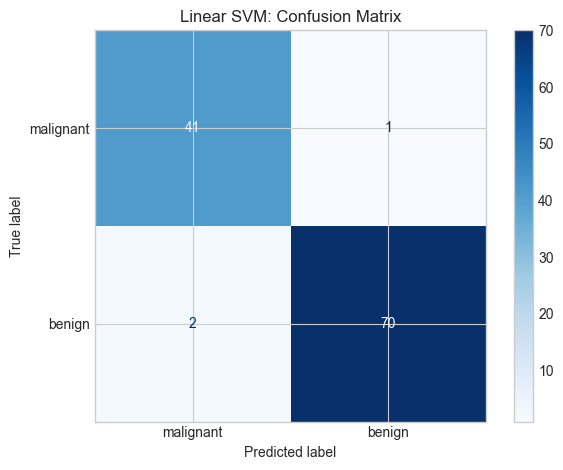

Best parameters: {'svm__C': 0.1}
Best cross-validation F1-score: 0.9828

Tuned linear SVM metrics
Accuracy     0.9825
Precision    0.9861
Recall       0.9861
F1-score     0.9861
Name: Tuned linear SVM, dtype: float64


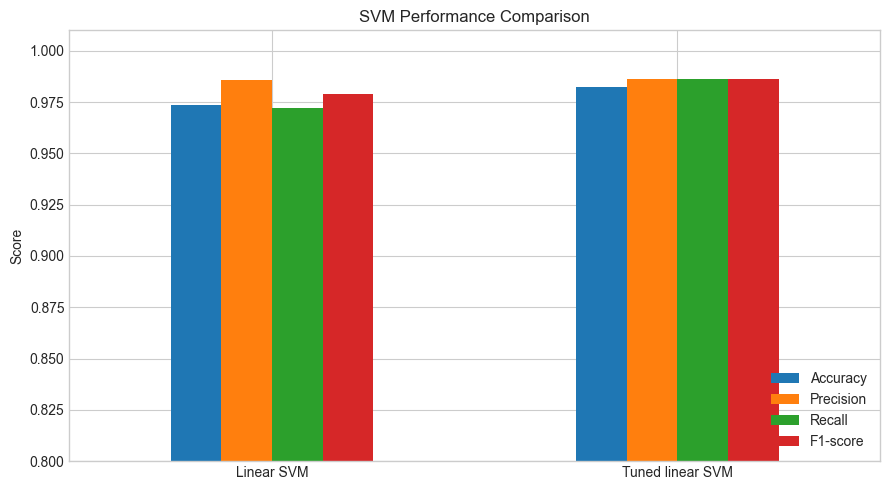

Observation: standardization is important for SVM because the margin and regularization depend on feature scale. Grid search selects C using only the training folds, while the final test set is used once for evaluation.


In [ ]:
# Lab 9: Support Vector Machine (SVM) and Principal Component Analysis (PCA)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer, load_wine
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.decomposition import PCA

RANDOM_STATE = 42
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["figure.facecolor"] = "white"

# Part A: Support Vector Machine classification
breast_cancer = load_breast_cancer(as_frame=True)
X_cancer = breast_cancer.data
y_cancer = breast_cancer.target

X_train, X_test, y_train, y_test = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_cancer,
)

linear_svm = Pipeline(
    [
        ("scaler", StandardScaler()),
        ("svm", SVC(kernel="linear")),
    ]
)

linear_svm.fit(X_train, y_train)
y_pred = linear_svm.predict(X_test)

svm_metrics = pd.Series(
    {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-score": f1_score(y_test, y_pred),
    },
    name="Linear SVM",
)

print("Dataset shape:", X_cancer.shape)
print("Training samples:", X_train.shape[0], "| Testing samples:", X_test.shape[0])
print("\nLinear-kernel SVM metrics")
print(svm_metrics.round(4))
print("\nClassification report")
print(classification_report(y_test, y_pred, target_names=breast_cancer.target_names))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred),
    display_labels=breast_cancer.target_names,
).plot(cmap="coolwarm")
plt.title("Linear SVM: Confusion Matrix")
plt.tight_layout()
plt.show()

param_grid = {"svm__C": [0.01, 0.1, 1, 10, 100]}
grid_search = GridSearchCV(
    linear_svm,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

tuned_pred = grid_search.predict(X_test)
tuned_metrics = pd.Series(
    {
        "Accuracy": accuracy_score(y_test, tuned_pred),
        "Precision": precision_score(y_test, tuned_pred),
        "Recall": recall_score(y_test, tuned_pred),
        "F1-score": f1_score(y_test, tuned_pred),
    },
    name="Tuned linear SVM",
)
print("Best parameters:", grid_search.best_params_)
print("Best cross-validation F1-score:", round(grid_search.best_score_, 4))
print("\nTuned linear SVM metrics")
print(tuned_metrics.round(4))

svm_comparison = pd.DataFrame([svm_metrics, tuned_metrics])
svm_comparison.plot(
    kind="bar",
    figsize=(9, 5),
    ylim=(0.8, 1.01),
    rot=0,
    color=["#4C78A8", "#F58518"],
)
plt.ylabel("Score")
plt.title("SVM Performance Comparison")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

print(
    "Observation: standardization is important for SVM because the margin and "
    "regularization depend on feature scale. Grid search selects C using only "
    "the training folds, while the final test set is used once for evaluation."
)

Original wine dataset shape: (178, 13)
Two-component dataset shape: (178, 2)

Explained variance by component
 Principal Component  Explained Variance Ratio  Cumulative Explained Variance
                   1                    0.3620                         0.3620
                   2                    0.1921                         0.5541
                   3                    0.1112                         0.6653
                   4                    0.0707                         0.7360
                   5                    0.0656                         0.8016
                   6                    0.0494                         0.8510
                   7                    0.0424                         0.8934
                   8                    0.0268                         0.9202
                   9                    0.0222                         0.9424
                  10                    0.0193                         0.9617
                  11            

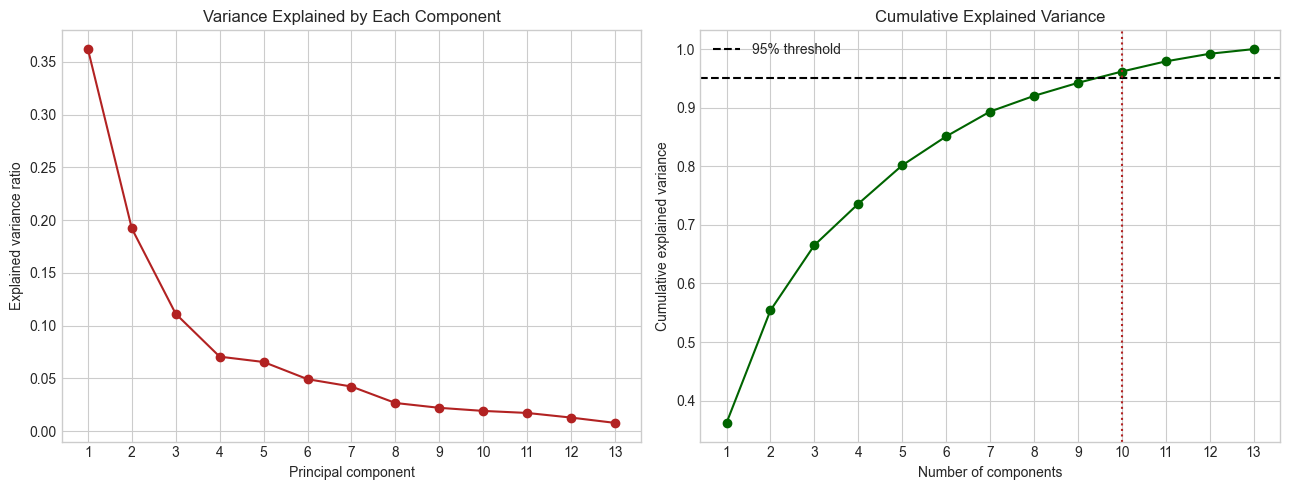

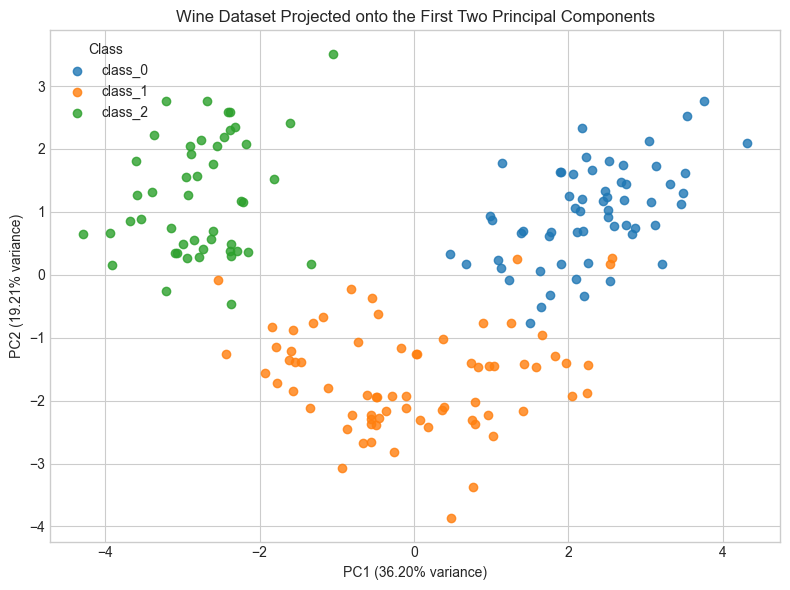

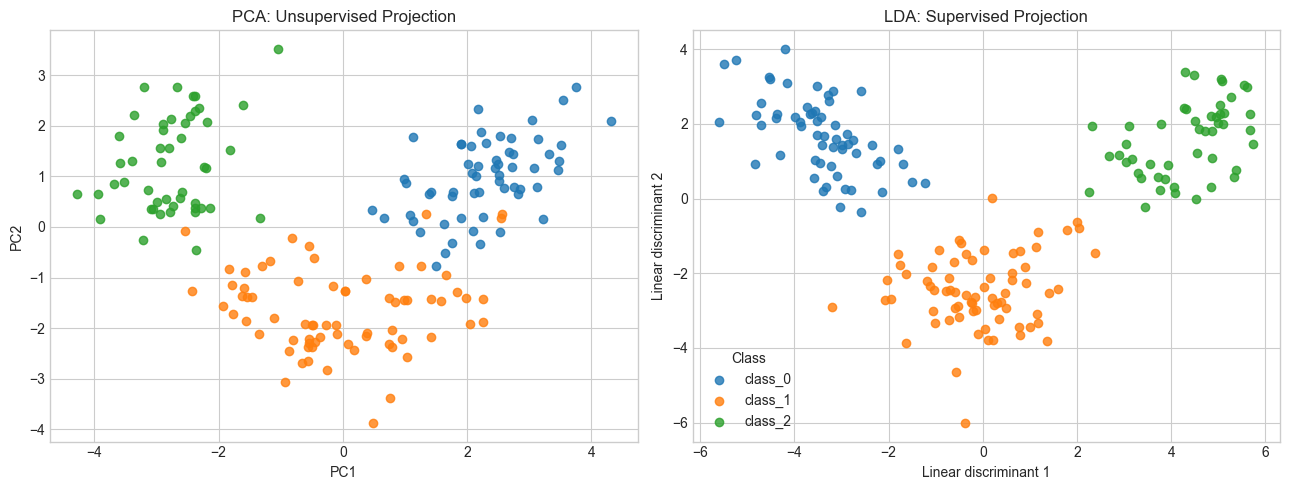

PCA variance retained by first two components: 0.5541
LDA variance ratios: [0.6875 0.3125]

Comparison
- Original data: 13 features and 178 samples.
- PCA data: 2 features, preserving 55.41 % of total variance.
- LDA data: 2 supervised discriminants, chosen for class separation rather than total variance.
- PCA is useful for visualization, compression, noise reduction, and preprocessing, but its directions may not separate classes.
- PCA limitations include information loss, reduced interpretability, sensitivity to scaling, and sensitivity to outliers.
- LDA is often better when labeled classes must be separated, but it requires labels and assumes class distributions with reasonably similar covariance structure.
- The largest absolute loadings in pca_2d.components_ indicate which original features contribute most to PC1 and PC2.

PCA loadings
                              PC1 loading  PC2 loading
flavanoids                         0.4229      -0.0034
total_phenols                      

In [ ]:
# Part B: Principal Component Analysis on the UCI Wine dataset
wine = load_wine(as_frame=True)
X_wine = wine.data
y_wine = wine.target

wine_scaler = StandardScaler()
X_wine_scaled = wine_scaler.fit_transform(X_wine)

pca_full = PCA()
X_wine_pca_full = pca_full.fit_transform(X_wine_scaled)
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)
components_for_95 = np.argmax(cumulative_variance >= 0.95) + 1

variance_table = pd.DataFrame(
    {
        "Principal Component": np.arange(1, len(explained_variance) + 1),
        "Explained Variance Ratio": explained_variance,
        "Cumulative Explained Variance": cumulative_variance,
    }
)
print("Original wine dataset shape:", X_wine.shape)
print("Two-component dataset shape:", X_wine_pca_full[:, :2].shape)
print("\nExplained variance by component")
print(variance_table.round(4).to_string(index=False))
print("\nMinimum components retaining at least 95% variance:", components_for_95)

plt.figure(figsize=(8, 5), facecolor="white")
plt.plot(
    np.arange(1, len(explained_variance) + 1),
    explained_variance,
    marker="o",
    color="#4063D8",
    linewidth=2,
)
plt.xlabel("Principal component")
plt.ylabel("Explained variance ratio")
plt.title("Variance Explained by Each Component")
plt.xticks(np.arange(1, len(explained_variance) + 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5), facecolor="white")
plt.plot(
    np.arange(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker="o",
    color="#2AA876",
    linewidth=2,
)
plt.axhline(0.95, color="#000000", linestyle="--", label="95% threshold")
plt.axvline(components_for_95, color="#D62728", linestyle=":")
plt.xlabel("Number of components")
plt.ylabel("Cumulative explained variance")
plt.title("Cumulative Explained Variance")
plt.xticks(np.arange(1, len(cumulative_variance) + 1))
plt.legend()
plt.tight_layout()
plt.show()

# The first two components are the requested two-dimensional representation.
pca_2d = PCA(n_components=2)
X_wine_pca_2d = pca_2d.fit_transform(X_wine_scaled)

colors = plt.cm.Set2(np.linspace(0, 1, len(wine.target_names)))
plt.figure(figsize=(8, 6), facecolor="white")
for class_id, class_name in enumerate(wine.target_names):
    class_points = X_wine_pca_2d[y_wine == class_id]
    plt.scatter(
        class_points[:, 0],
        class_points[:, 1],
        label=class_name,
        alpha=0.8,
        s=50,
        color=colors[class_id],
    )
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.title("Wine Dataset Projected onto the First Two Principal Components")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

# Extra credit: LDA is supervised and can use class labels to maximize separation.
lda_2d = LinearDiscriminantAnalysis(n_components=2)
X_wine_lda_2d = lda_2d.fit_transform(X_wine_scaled, y_wine)

plt.figure(figsize=(8, 6), facecolor="white")
for class_id, class_name in enumerate(wine.target_names):
    lda_points = X_wine_lda_2d[y_wine == class_id]
    plt.scatter(
        lda_points[:, 0],
        lda_points[:, 1],
        label=class_name,
        alpha=0.8,
        s=50,
        color=colors[class_id],
    )
plt.title("LDA: Supervised Projection")
plt.xlabel("Linear discriminant 1")
plt.ylabel("Linear discriminant 2")
plt.legend(title="Class")
plt.tight_layout()
plt.show()

print("PCA variance retained by first two components:", round(pca_2d.explained_variance_ratio_.sum(), 4))
print("LDA variance ratios:", np.round(lda_2d.explained_variance_ratio_, 4))
print("\nComparison")
print("- Original data: 13 features and", X_wine.shape[0], "samples.")
print("- PCA data: 2 features, preserving", round(pca_2d.explained_variance_ratio_.sum() * 100, 2), "% of total variance.")
print("- LDA data: 2 supervised discriminants, chosen for class separation rather than total variance.")
print("- PCA is useful for visualization, compression, noise reduction, and preprocessing, but its directions may not separate classes.")
print("- PCA limitations include information loss, reduced interpretability, sensitivity to scaling, and sensitivity to outliers.")
print("- LDA is often better when labeled classes must be separated, but it requires labels and assumes class distributions with reasonably similar covariance structure.")
print("- The largest absolute loadings in pca_2d.components_ indicate which original features contribute most to PC1 and PC2.")

loadings = pd.DataFrame(
    pca_2d.components_.T,
    index=X_wine.columns,
    columns=["PC1 loading", "PC2 loading"],
)

print("\nPCA loadings")
print(loadings.round(4).apply(lambda col: col.abs()).sort_values("PC1 loading", ascending=False).head(8))